# Stillaguamish Build Scripts
May 17, 2026

List of scripts:
1. Observation points geojson from channel
2. Quadtree Grid Generation
4. Sanity Check Plots
5. Input Files
6. Benchmark Read

## Generate Observation Points File

In [1]:
import numpy as np
from shapely.geometry import LineString
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import geopandas as gpd

parent_dir = '/home/cassandra/Snohomish/2026-05-17-Stillaguamish/'
channel_file = parent_dir + 'channel_lines.geojson'
obs_file     = parent_dir + 'obs.geojson'

obs_geoms = []
obs_names = []

channel = gpd.read_file(channel_file)
for i, name in enumerate(['main', 'side1', 'side2']):
    line = channel.geometry[i]
    distances = np.arange(0, line.length, 1000.0)
    for distance in distances:
        obs_geoms.append(line.interpolate(distance))
        obs_names.append(name + '-' + str(int(distances[i]/1000)) + 'km"')
        
obs = gpd.GeoDataFrame(geometry=obs_geoms, data={'name':obs_names}, crs='EPSG:32610')
obs.to_file(parent_dir + "obs.geojson")

## Build Quadtree

### Files, Imports

In [2]:
from hydromt_sfincs import SfincsModel

import os
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr

parent_dir = '/home/cassandra/Snohomish/2026-05-17-Stillaguamish/'

DEM_PATH = '/home/cassandra/Data/CoNED_StillyFull_dredge_v3/CoNED_StillyFull_dredge_v3.tif'
MAN_PATH = parent_dir + "Stillaguamish_manning_fixed.tif"
manning_override = 0.02


required_files = {
    "DEM":               DEM_PATH,
    "MAN":               MAN_PATH,
    "include":           parent_dir + "include.geojson",
    "offshore_boundary": parent_dir + "offshore_boundary.geojson",
    "refine_20m":        parent_dir + "refine_20m.geojson",
    "refine_10m":        parent_dir + "refine_10m.geojson",
    "levees":            parent_dir + "levees.geojson",
    "obs":               parent_dir + "obs.geojson"
}

# Prep geodataframes, lists, etc
include_gdf  = gpd.read_file(required_files['include'])
offshore_gdf = gpd.read_file(required_files['offshore_boundary'])
levees_gdf   = gpd.read_file(required_files['levees'])
obs_gdf      = gpd.read_file(required_files['obs'])

refine_specs = [
    (required_files['refine_20m'], 3),
    (required_files['refine_10m'], 4)
]

refine_parts = []
for fpath, level in refine_specs:
    gdf = gpd.read_file(fpath)
    gdf = gdf[["geometry"]].copy()
    gdf["refinement_level"] = level
    refine_parts.append(gdf)

refinement_gdf = gpd.GeoDataFrame(
    pd.concat(refine_parts, ignore_index=True), crs=include_gdf.crs
)

elevation_list = [{"elevation": required_files['DEM']}]
roughness_list = [{"manning"  : required_files['MAN']}]

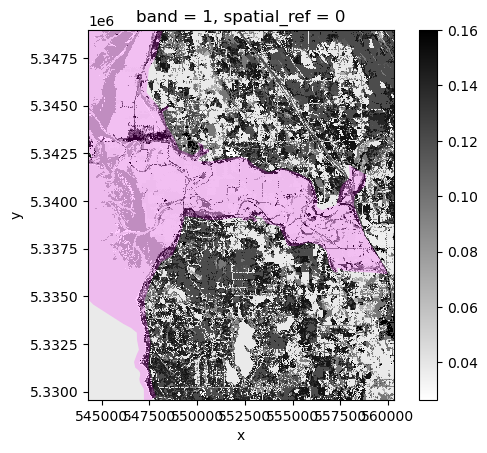

In [3]:
import rioxarray
import matplotlib.pyplot as plt

manning = rioxarray.open_rasterio(required_files['MAN'])

fig = plt.figure()
ax = fig.add_subplot(111)
manning.plot(ax=ax, cmap='binary')
include_gdf.plot(ax=ax, color='magenta', alpha=0.2)
plt.show()

### Grid Build

In [4]:
sf = SfincsModel(root=parent_dir, mode="w+")

sf.quadtree_grid.create_from_region(
    region={"geom": include_gdf},
    res=160,
    crs=32610,
    rotated=False,
    refinement_polygons=refinement_gdf,
)

sf.quadtree_elevation.create(
    elevation_list=elevation_list,
    interp_method="linear",
    buffer_cells=1,
)

sf.quadtree_mask.create_active(
    include_polygon=include_gdf,
)

sf.quadtree_mask.create_boundary(
    btype="waterlevel",
    include_polygon=offshore_gdf,
    reset_bounds=True,
)

sf.quadtree_roughness.create(
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_sea=manning_override,
    rgh_lev_land=0,   # z = 0 m as land/sea boundary
)

sf.weirs.create(
    locations=levees_gdf,
    dep=DEM_PATH,   # sample crest elevation from DEM
    merge=False,
)

sf.observation_points.create(
    locations=obs_gdf,
    merge=False,
)

No region component found in components.


Refining ...
Time elapsed : 9.536181449890137 s
Finding neighbors ...
Time elapsed : 0.02186727523803711 s
Setting neighbors left and below ...
Time elapsed : 0.15241718292236328 s
Getting uv points ...
Time elapsed : 0.0832059383392334 s
Making XUGrid ...
Got rid of duplicates in 0.3223 seconds
Made XUGrid in 0.0014 seconds


overwriting data source 'CoNED_StillyFull_dredge_v3.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'CoNED_StillyFull_dredge_v3.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'CoNED_StillyFull_dredge_v3.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'CoNED_StillyFull_dredge_v3.tif' with provider user and version _UNSPECIFIED_.
Replacing mesh parameter: z
nodata value missing for /home/cassandra/Snohomish/2026-05-17-Stillaguamish/Stillaguamish_manning_fixed.tif
overwriting data source 'CoNED_StillyFull_dredge_v3.tif' with provider user and version _UNSPECIFIED_.
Weir point 547475.8304665525 5349618.147094072 has no elevation data. Filled now with nearest non-NaN value. Please check your input!


In [5]:
%%capture cap 
# "Magic Command" to squash cell output

sf.quadtree_subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_water=manning_override,
    manning_level=0.0, # z = 0 m as land/sea boundary
    nr_subgrid_pixels=20,
    nr_levels=20,
    write_dep_tif=False,
    write_man_tif=False,
    nrmax=2000,
)

In [6]:
sf.write()

### Plots, etc

(<Figure size 600x442.509 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

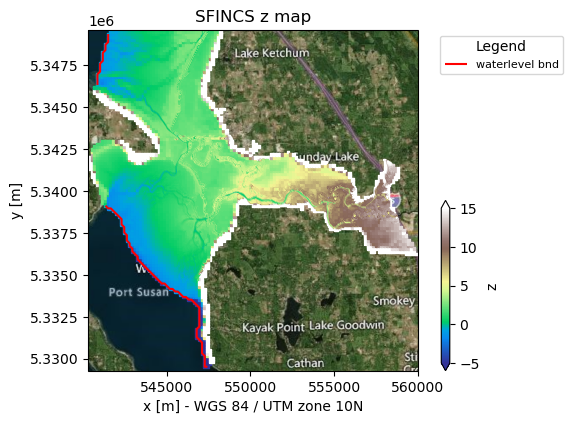

In [7]:
sf.plot_basemap(
    variable="elevation", plot_region=False, plot_geoms = False, 
    plot_bounds=True, bmap="sat", vmin=-5, vmax=15,
)

(<Figure size 600x442.509 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS manning map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

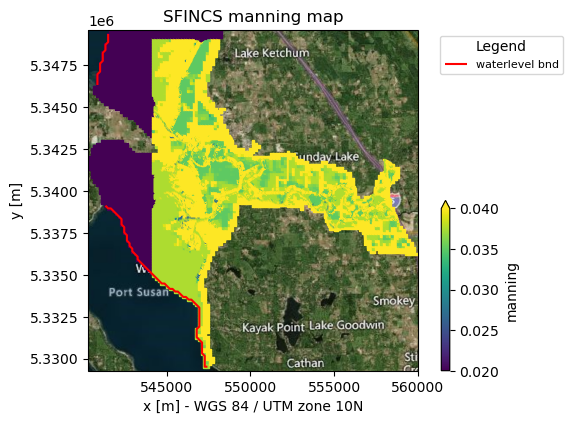

In [8]:
sf.plot_basemap(
    variable="manning", plot_region=False, plot_geoms = False, plot_bounds=True, 
    bmap="sat", vmin=0.02, vmax=0.04,
)

In [9]:
import xugrid as xu

x_qtr = xu.load_dataset(parent_dir + 'sfincs.nc')
x_qtr.z.ugrid.to_netcdf(parent_dir + 'qtr_z.nc')
x_qtr.mask.astype(float).ugrid.to_netcdf(parent_dir + 'qtr_mask.nc')

### Get Subset of Delft3D-FM Points in Stillaguamish Vicinity

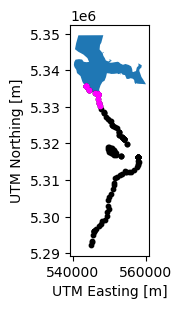

In [11]:
import utm
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point

parent_dir = '/home/cassandra/Snohomish/2026-05-17-Stillaguamish/'
include_gdf  = gpd.read_file(parent_dir + 'include.geojson')

wl = xr.open_dataset('/media/cassandra/Expansion/Regional_ERA5_WlWaves_Snohomish.nc', decode_cf=False)
minutes = wl.time.values.astype(int)
time = np.datetime64('1940-01-01T00:00') + minutes.astype('timedelta64[m]')
lat, lon = wl.lat_wl.values, wl.lon_wl.values
x, y, _, __ = utm.from_latlon(lat, lon)

ok = np.zeros(len(x), dtype=bool)
for i in range(len(x)):
    ok[i] = include_gdf.contains(Point(x[i],y[i]))[0]

fig, ax = plt.subplots(figsize=(4,3))
plt.scatter(x, y, color='black', s=10, zorder=3)
plt.scatter(x[ok], y[ok], color='magenta', s=10, zorder=3)
plt.xlabel("UTM Easting [m]")
plt.ylabel("UTM Northing [m]")
include_gdf.plot(ax=ax)
plt.show()

### Shared input files

In [12]:
import xarray as xr
import numpy as np
import os
import utm

parent_dir = '/home/cassandra/Snohomish/2026-05-17-Stillaguamish/'
template_file = parent_dir + 'sfincs_template.inp'

# Load discharge and water level data set
# I reformatted the wflow output, selecting only the discharge points I wanted
discharge  = xr.open_dataset(parent_dir + 'wflow.nc')
# Associated location array
da_loc_array = np.column_stack([discharge.x.values, discharge.y.values])

# Original formatting -- giant file though! Be ware!
waterlevel = xr.open_dataset('/media/cassandra/Expansion/Regional_ERA5_WlWaves_Snohomish.nc')
# Water level timestep needs manual loading...
minutes = waterlevel.time.values.astype(int)
time = np.datetime64('1940-01-01T00:00') + minutes.astype('timedelta64[m]')
# Location array for water levels
lat, lon = waterlevel.lat_wl.values, waterlevel.lon_wl.values
x, y, _, __ = utm.from_latlon(lat, lon)
# Use only points near Stillaguamish
wl_loc_array = np.column_stack([x[ok], y[ok]])

# Make input files associated with the water level / discharge source locations
np.savetxt(parent_dir + "sfincs.src", da_loc_array, fmt="%.3f")
np.savetxt(parent_dir + "sfincs.bnd", wl_loc_array, fmt="%.3f")

### Yearly Inputs

In [15]:
def make_model(t0, tf, model_dir, DTMAPOUT='2592000'):
    # Discharge Input
    sda = discharge.sel(time=slice(t0, tf))
    Q = sda.discharge.values  # shape (T, L)
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (sda.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, Q])
    fmt = ["%.1f"] + ["%.3f"] * Q.shape[1]
    np.savetxt(model_dir + "sfincs.dis", out, fmt=fmt)

    # Water Level Input
    swl = waterlevel.sel(time=slice(t0, tf))
    eta = swl.tide[ok].values 
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (swl.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, eta.T])
    fmt = ["%.1f"] + ["%.3f"] * eta.shape[0]
    np.savetxt(model_dir + "sfincs.bzs", out, fmt=fmt)

    # Create sfincs.inp from template
    input_template_file = open(template_file, 'r')
    input_template = input_template_file.read()
    tstart = str(t0)[:10].replace('-', '') + ' ' + str(t0)[11:].replace(':', '')
    tstop  = str(tf)[:10].replace('-', '') + ' ' + str(tf)[11:].replace(':', '')
    input_file_content = input_template.format(TSTART=tstart, 
                                               TSTOP=tstop, 
                                               TREF=tstart,
                                               DTMAPOUT=DTMAPOUT)
    input_file = open(model_dir + 'sfincs.inp', "w")
    input_file.write(input_file_content)
    input_file.close()

In [16]:
# Buffer for spinup time. 1 week. 
buffer = np.timedelta64(7*24*60, 'm')

# For each WATER year... 
for year in np.arange(1942, 2024, 1):
    
    # Get start and stop timestamps
    # Water year for 2000 runs from 1999-10-01 through 2000-09-30 so...
    t0 = np.datetime64(str(year-1) + '-10-01T00:00') - buffer
    tf = np.datetime64(str(year)   + '-10-01T00:00')

    # Make model directory
    model_dir = parent_dir + str(year) + '/'
    if not os.path.exists(model_dir):
        os.mkdir(model_dir)

    # Make model input files
    make_model(t0, tf, model_dir)

In [17]:
# Feb 2016 benchmark event
t0 = np.datetime64('2016-02-10T00:00')
tf = np.datetime64('2016-02-25T00:00')

model_dir = parent_dir + "benchmark" + '/'
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

make_model(t0, tf, model_dir, DTMAPOUT='1800')

## Benchmark read

In [18]:
from hydromt_sfincs import SfincsModel

parent_dir = '/home/cassandra/Snohomish/2026-05-17-Stillaguamish/'
bench_dir = parent_dir + 'benchmark/'

sf = SfincsModel(root=bench_dir, mode="r")
sf.output.read()

No region component found in components.
Replacing result: inp
Replacing result: crs
Replacing result: zb
Replacing result: msk
Replacing result: zs
Replacing result: zsmax
Replacing result: qmax
Replacing result: total_runtime
Replacing result: average_dt
Replacing result: status


In [22]:
sbg = xr.open_dataset(parent_dir + 'sfincs_subgrid.nc')
zmin = sbg.z_zmin.values

In [29]:
hmax = sf.output.data["zsmax"].max(dim="timemax") - zmin
hmax = hmax.where(hmax > 0.1)
hmax.attrs.update(long_name="flood depth", unit="m")

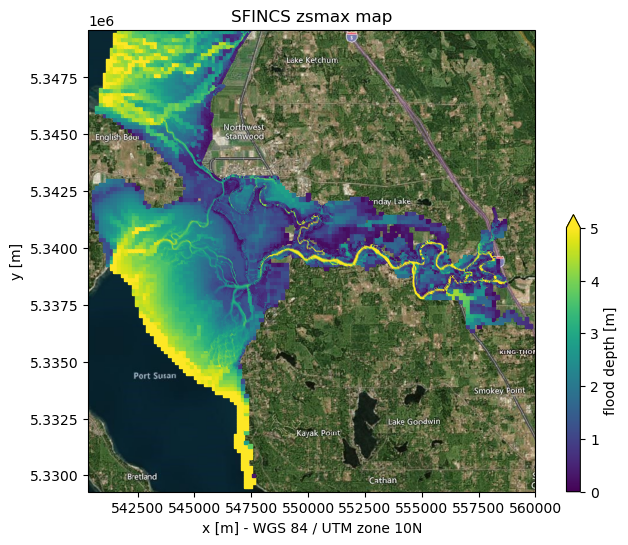

In [30]:
fig, ax = sf.plot_basemap(
    fn_out=None,
    figsize=(8, 6),
    variable=hmax,
    plot_bounds=False,
    plot_geoms=False,
    bmap="sat",
    zoomlevel=12,
    vmin=0.0,
    vmax=5.0,
    cbar_kwargs={"shrink": 0.6, "anchor": (0, 0)},
)